# Système de Reconnaissance Faciale
## FaceNet vs VGGFace2 — Dataset LFW


In [ ]:
!pip install torch torchvision facenet-pytorch scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms, models
from facenet_pytorch import InceptionResnetV1
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {device}')

Device utilisé : cpu


In [ ]:
#  Chargement du dataset LFW
lfw_dataset = fetch_lfw_people(min_faces_per_person=20, resize=0.5)
images      = lfw_dataset.images
labels      = lfw_dataset.target
label_names = lfw_dataset.target_names

print(f'Nombre d\'images  : {len(images)}')
print(f'Nombre de classes : {len(label_names)}')

Nombre d'images  : 3023
Nombre de classes : 62


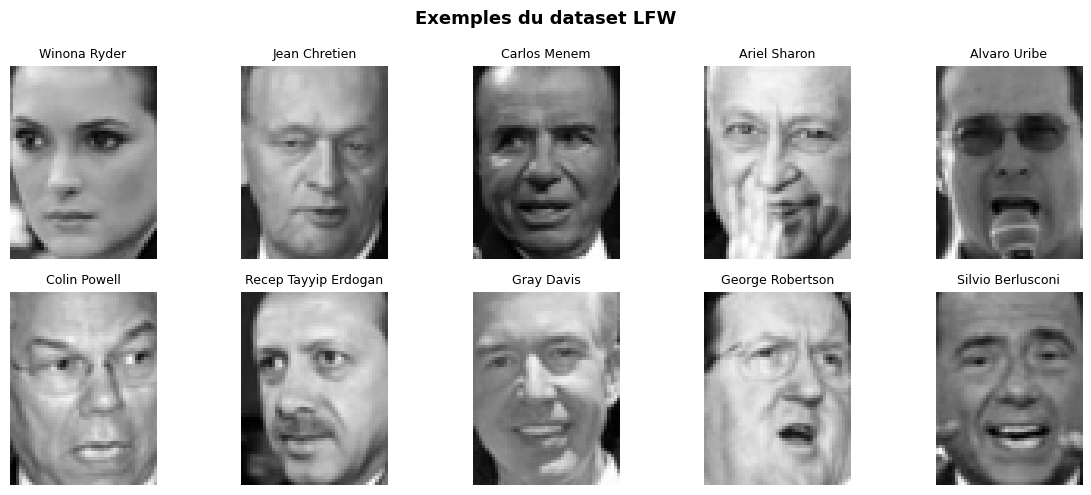

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(label_names[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Exemples du dataset LFW', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Génération des paires de test

On génère 500 paires aléatoires :
- **Paires positives** : deux images de la **même** personne (label = 1)
- **Paires négatives** : deux images de personnes **différentes** (label = 0)

> Le seed est fixé à 42 pour garantir une comparaison équitable entre les deux modèles.

In [ ]:
NUM_PAIRS = 500
SEED      = 42

def generate_pairs(labels, num_pairs=NUM_PAIRS, seed=SEED):
    np.random.seed(seed)
    pairs  = []
    y_true = []
    for _ in range(num_pairs):
        if np.random.rand() > 0.5:
            person = np.random.choice(np.unique(labels))
            idxs   = np.where(labels == person)[0]
            i1, i2 = np.random.choice(idxs, size=2, replace=False)
            y_true.append(1)
        else:
            p1, p2 = np.random.choice(np.unique(labels), size=2, replace=False)
            i1 = np.random.choice(np.where(labels == p1)[0])
            i2 = np.random.choice(np.where(labels == p2)[0])
            y_true.append(0)
        pairs.append((i1, i2))
    return pairs, y_true

pairs, y_true = generate_pairs(labels)
print(f'Paires générées : {len(pairs)}')
print(f'Positives : {sum(y_true)}  |  Négatives : {len(y_true) - sum(y_true)}')

Paires générées : 500
Positives : 242  |  Négatives : 258


---
# PARTIE 1 — FaceNet

**FaceNet** repose sur l'architecture InceptionResnetV1 et génère un embedding de 512 dimensions pour chaque visage. La similarité entre deux visages est mesurée par le cosinus, et le modèle est initialisé avec des poids pré-entraînés sur le dataset VGGFace2.

In [ ]:
# Chargement du modèle FaceNet

model_facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
print('Modèle FaceNet (InceptionResnetV1) chargé.')

transform_facenet = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

  0%|          | 0.00/107M [00:00<?, ?B/s]

Modèle FaceNet (InceptionResnetV1) chargé.


In [ ]:
# Calcul des embeddings FaceNet
embeddings_fn = []

for img in images:
    tensor = transform_facenet(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model_facenet(tensor)
    embeddings_fn.append(emb.cpu())

embeddings_fn = torch.cat(embeddings_fn)
print(f'FaceNet embeddings shape : {embeddings_fn.shape}')

FaceNet embeddings shape : torch.Size([3023, 512])


In [ ]:
# Calcul des scores de similarité cosinus
y_scores_fn = []

for i1, i2 in pairs:
    sim = F.cosine_similarity(
        embeddings_fn[i1].unsqueeze(0),
        embeddings_fn[i2].unsqueeze(0)
    ).item()
    y_scores_fn.append(sim)

print(f'Score moyen (positifs) : {np.mean([s for s, t in zip(y_scores_fn, y_true) if t==1]):.4f}')
print(f'Score moyen (négatifs) : {np.mean([s for s, t in zip(y_scores_fn, y_true) if t==0]):.4f}')

Score moyen (positifs) : 0.7330
Score moyen (négatifs) : 0.0672


In [ ]:
#  Évaluation — FAR, FRR, ROC, AUC
fpr_fn, tpr_fn, _ = roc_curve(y_true, y_scores_fn)
roc_auc_fn = auc(fpr_fn, tpr_fn)
print(f'FaceNet AUC : {roc_auc_fn:.3f}\n')

print('Seuil  | FAR   | FRR')
print('-' * 25)
for thr in [0.5, 0.6, 0.7, 0.8, 0.9]:
    far = np.mean([1 if s > thr and t == 0 else 0 for s, t in zip(y_scores_fn, y_true)])
    frr = np.mean([1 if s <= thr and t == 1 else 0 for s, t in zip(y_scores_fn, y_true)])
    print(f'  {thr:.1f}  | {far:.3f} | {frr:.3f}')

FaceNet AUC : 1.000

Seuil  | FAR   | FRR
-------------------------
  0.5  | 0.000 | 0.014
  0.6  | 0.000 | 0.060
  0.7  | 0.000 | 0.156
  0.8  | 0.000 | 0.344
  0.9  | 0.000 | 0.466


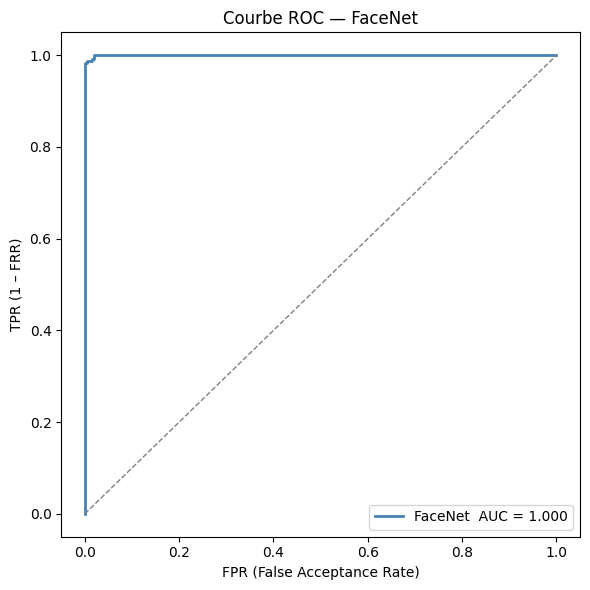

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr_fn, tpr_fn, color='steelblue', lw=2, label=f'FaceNet  AUC = {roc_auc_fn:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=1)
plt.xlabel('FPR (False Acceptance Rate)')
plt.ylabel('TPR (1 – FRR)')
plt.title('Courbe ROC — FaceNet')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# une fonction pour comparer deux images avec FaceNet et en retour elle donne un score + False ou True
def compare_facenet(img1, img2, threshold=0.8):

    t1 = transform_facenet(img1).unsqueeze(0).to(device)
    t2 = transform_facenet(img2).unsqueeze(0).to(device)
    with torch.no_grad():
        e1 = model_facenet(t1)
        e2 = model_facenet(t2)
    score = F.cosine_similarity(e1, e2).item()
    return score > threshold, score

# Test sur même image donc il doit retourner True et score ≈ 1.0
same, score = compare_facenet(images[0], images[0])
print(f'Même image  → Même personne : {same}  |  Score : {score:.4f}')

# Testssur des images différentes
same2, score2 = compare_facenet(images[0], images[5])
print(f'Images diff → Même personne : {same2}  |  Score : {score2:.4f}')

Même image  → Même personne : True  |  Score : 1.0000
Images diff → Même personne : False  |  Score : -0.1476


---
# PARTIE 2 — VGGFace2

VGGFace2 utilise une architecture ResNet-50 dont la couche fully connected est remplacée par une projection en vecteur de dimension 512, normalisé par L2. Les visages sont redimensionnés en 224×224 en entrée, et la similarité entre deux embeddings est mesurée par le cosinus.

### 2.1 Définition et chargement du modèle VGGFace2

In [ ]:
class VGGFace2ResNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = torch.nn.Sequential(*list(backbone.children())[:-1])
        self.embed    = torch.nn.Linear(2048, 512)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.embed(x)
        x = F.normalize(x, p=2, dim=1)
        return x

model_vgg = VGGFace2ResNet().eval().to(device)
print('Modèle VGGFace2-ResNet50 chargé.')

transform_vgg = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]


Modèle VGGFace2-ResNet50 chargé.


In [ ]:
# Calcul des embeddings VGGFace2
embeddings_vgg = []

for img in images:
    tensor = transform_vgg(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model_vgg(tensor)
    embeddings_vgg.append(emb.cpu())

embeddings_vgg = torch.cat(embeddings_vgg)
print(f'VGGFace2 embeddings shape : {embeddings_vgg.shape}')

VGGFace2 embeddings shape : torch.Size([3023, 512])


In [ ]:
# Calcul des scores de similarité cosinus
y_scores_vgg = []

for i1, i2 in pairs:
    sim = F.cosine_similarity(
        embeddings_vgg[i1].unsqueeze(0),
        embeddings_vgg[i2].unsqueeze(0)
    ).item()
    y_scores_vgg.append(sim)

print(f'Score moyen (positifs) : {np.mean([s for s, t in zip(y_scores_vgg, y_true) if t==1]):.4f}')
print(f'Score moyen (négatifs) : {np.mean([s for s, t in zip(y_scores_vgg, y_true) if t==0]):.4f}')

Score moyen (positifs) : 0.9134
Score moyen (négatifs) : 0.8845


In [ ]:
#  Évaluation — FAR, FRR, ROC, AUC
fpr_vgg, tpr_vgg, _ = roc_curve(y_true, y_scores_vgg)
roc_auc_vgg = auc(fpr_vgg, tpr_vgg)
print(f'VGGFace2 AUC : {roc_auc_vgg:.3f}\n')

print('Seuil  | FAR   | FRR')
print('-' * 25)
for thr in [0.5, 0.6, 0.7, 0.8, 0.9]:
    far = np.mean([1 if s > thr and t == 0 else 0 for s, t in zip(y_scores_vgg, y_true)])
    frr = np.mean([1 if s <= thr and t == 1 else 0 for s, t in zip(y_scores_vgg, y_true)])
    print(f'  {thr:.1f}  | {far:.3f} | {frr:.3f}')

VGGFace2 AUC : 0.724

Seuil  | FAR   | FRR
-------------------------
  0.5  | 0.516 | 0.000
  0.6  | 0.516 | 0.000
  0.7  | 0.516 | 0.000
  0.8  | 0.496 | 0.002
  0.9  | 0.202 | 0.126


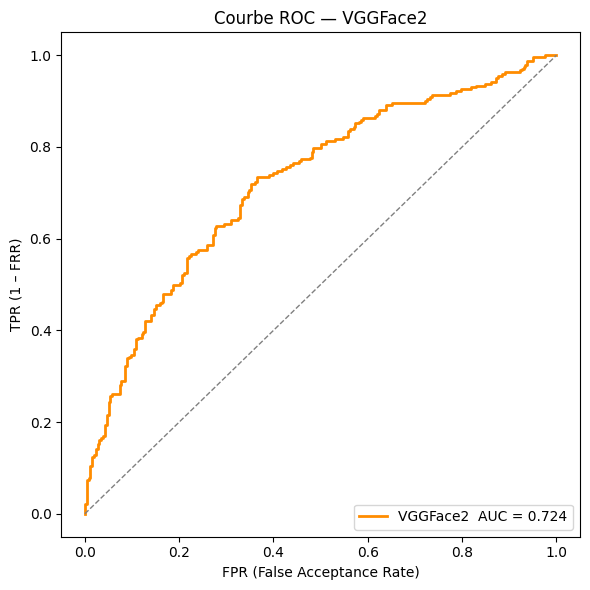

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr_vgg, tpr_vgg, color='darkorange', lw=2, label=f'VGGFace2  AUC = {roc_auc_vgg:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=1)
plt.xlabel('FPR (False Acceptance Rate)')
plt.ylabel('TPR (1 – FRR)')
plt.title('Courbe ROC — VGGFace2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# fonction pour comparer deux images avec VGGFace2
def compare_vggface2(img1, img2, threshold=0.7):

    t1 = transform_vgg(img1).unsqueeze(0).to(device)
    t2 = transform_vgg(img2).unsqueeze(0).to(device)
    with torch.no_grad():
        e1 = model_vgg(t1)
        e2 = model_vgg(t2)
    score = F.cosine_similarity(e1, e2).item()
    return score > threshold, score

# Test sur même image il doit retourner True et score ≈ 1.0
same, score = compare_vggface2(images[0], images[0])
print(f'Même image  → Même personne : {same}  |  Score : {score:.4f}')

# Test sur des images differente
same2, score2 = compare_vggface2(images[0], images[19])
print(f'Images diff → Même personne : {same2}  |  Score : {score2:.4f}')

Même image  → Même personne : True  |  Score : 1.0000
Images diff → Même personne : True  |  Score : 0.8763


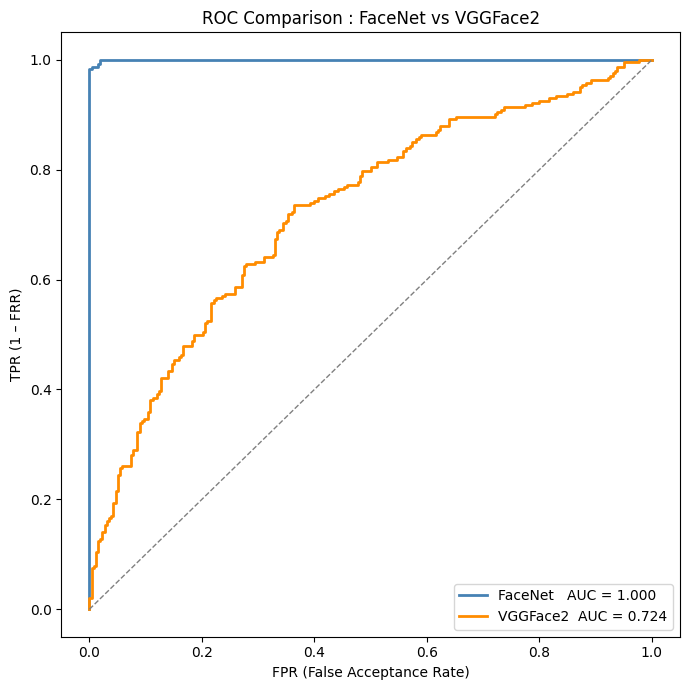

In [ ]:
# Comparaison finale — FaceNet vs VGGFace2
plt.figure(figsize=(7, 7))
plt.plot(fpr_fn,  tpr_fn,  color='steelblue',  lw=2, label=f'FaceNet   AUC = {roc_auc_fn:.3f}')
plt.plot(fpr_vgg, tpr_vgg, color='darkorange', lw=2, label=f'VGGFace2  AUC = {roc_auc_vgg:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=1)
plt.xlabel('FPR (False Acceptance Rate)')
plt.ylabel('TPR (1 – FRR)')
plt.title('ROC Comparison : FaceNet vs VGGFace2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# Tableau comparatif FAR/FRR
print(f'{"Seuil":^8} | {"FaceNet FAR":^12} | {"FaceNet FRR":^12} | {"VGGFace2 FAR":^13} | {"VGGFace2 FRR":^13}')
print('-' * 68)
for thr in [0.5, 0.6, 0.7, 0.8, 0.9]:
    far_fn  = np.mean([1 if s > thr and t == 0 else 0 for s, t in zip(y_scores_fn,  y_true)])
    frr_fn  = np.mean([1 if s <= thr and t == 1 else 0 for s, t in zip(y_scores_fn,  y_true)])
    far_vgg = np.mean([1 if s > thr and t == 0 else 0 for s, t in zip(y_scores_vgg, y_true)])
    frr_vgg = np.mean([1 if s <= thr and t == 1 else 0 for s, t in zip(y_scores_vgg, y_true)])
    print(f'  {thr:.1f}   |    {far_fn:.3f}     |    {frr_fn:.3f}     |     {far_vgg:.3f}     |     {frr_vgg:.3f}')

 Seuil   | FaceNet FAR  | FaceNet FRR  | VGGFace2 FAR  | VGGFace2 FRR 
--------------------------------------------------------------------
  0.5   |    0.000     |    0.014     |     0.516     |     0.000
  0.6   |    0.000     |    0.060     |     0.516     |     0.000
  0.7   |    0.000     |    0.156     |     0.516     |     0.000
  0.8   |    0.000     |    0.344     |     0.496     |     0.002
  0.9   |    0.000     |    0.466     |     0.202     |     0.126


In [ ]:
print('Resultat final :')
print(f' AUC FaceNet  : {roc_auc_fn:.3f}')
print(f'  AUC VGGFace2  : {roc_auc_vgg:.3f}')
winner = 'FaceNet' if roc_auc_fn >= roc_auc_vgg else 'VGGFace2'
print(f' {winner} obtient le meilleur AUC sur LFW.')

Resultat final :
 AUC FaceNet  : 1.000
  AUC VGGFace2  : 0.724
 FaceNet obtient le meilleur AUC sur LFW.


In [ ]:
!pip install gradio

In [ ]:
from facenet_pytorch import MTCNN
import torch
import torch.nn.functional as F
import numpy as np

# Initialiser MTCNN pour la détection et le recadrage des visages
# pour FaceNet parce que il peut pas Recadre et aligne les visages
mtcnn = MTCNN(image_size=160, margin=10, device=device)

def verify_faces(img1, img2, model_choice):

    img1 = np.array(img1)
    img2 = np.array(img2)

    if model_choice == "FaceNet":
        # Détecter et recadrer les visages
        face1 = mtcnn(img1)
        face2 = mtcnn(img2)

        if face1 is None or face2 is None:
            return " Visage non détecté", 0.0

        face1 = face1.unsqueeze(0).to(device)
        face2 = face2.unsqueeze(0).to(device)
        with torch.no_grad():
            emb1 = model_facenet(face1)
            emb2 = model_facenet(face2)

        score = F.cosine_similarity(emb1, emb2).item()
        same = score > 0.75
        result = " Même personne" if same else " Personnes différentes"

    else:
        # VGGFace2 ne nécessite pas MTCNN
        img1_tensor = transform_vgg(img1).unsqueeze(0).to(device)
        img2_tensor = transform_vgg(img2).unsqueeze(0).to(device)
        with torch.no_grad():
            emb1 = model_vgg(img1_tensor)
            emb2 = model_vgg(img2_tensor)

        score = F.cosine_similarity(emb1, emb2).item()
        same = score > 0.7
        result = " Même personne" if same else "Personnes différentes"

    return result, round(score, 4)

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=verify_faces,
    inputs=[
        gr.Image(type="pil", label="Image 1"),
        gr.Image(type="pil", label="Image 2"),
        gr.Radio(["FaceNet", "VGGFace2"], label="Modèle")
    ],
    outputs=[
        gr.Textbox(label="Résultat"),
        gr.Number(label="Score de similarité")
    ],
    title="🔍 Vérification d'identité faciale",
    description="Comparer deux visages avec FaceNet ou VGGFace2"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c61648d1b4c871ddb5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
